# **성능관리_종합실습**

## **(1) 환경준비**

### **1) 라이브러리 불러오기**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random as rd

from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.backend import clear_session
from keras.optimizers import Adam
from keras.regularizers import l1, l2
from keras.callbacks import EarlyStopping

from keras.datasets import fashion_mnist

### **2) 함수만들기**

In [2]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### **3) 데이터 로딩**

In [3]:
(x_train, y_train), (x_val, y_val) = fashion_mnist.load_data()

rd.seed(20)
tr_id = rd.sample(range(60000), 4000)
va_id = rd.sample(range(10000), 1000)

x_train, y_train = x_train[tr_id], y_train[tr_id]
x_val, y_val = x_val[va_id], y_val[va_id]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

### **4) 데이터 둘러보기**

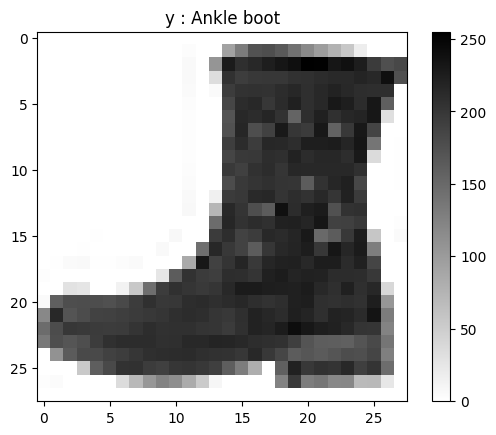

In [5]:
# 아래 숫자를 바꿔가며 화면에 그려 봅시다.
n = 1
i = y_val[n]

plt.imshow(x_val[n], cmap=plt.cm.binary)
plt.title(f'y : {class_names[i]}')
plt.colorbar()
plt.show()

## **(2) 데이터준비**

### 1) 데이터 2차원으로 펼치기

In [6]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((4000, 28, 28), (4000,), (1000, 28, 28), (1000,))

In [7]:
# 펼치기
x_train = x_train.reshape(4000, -1)
x_val = x_val.reshape(1000, -1)

In [8]:
x_train.shape, x_val.shape

((4000, 784), (1000, 784))

### 2) Scaling : Min-Max
* 0-255 값으로 되어 있는 데이터를 0-1사이 값으로 변환
* x_train, x_val를 그냥 255로 나누면 됨

In [9]:
x_train = x_train / 255.
x_val = x_val / 255.

## (3) 모델링

* 히든레이어의 노드를 다음과 같이 구성합니다.
    * 128, 64, 32, 16, 10
* epoch : 50 ~
* learning_rate : 0.01 ~ 0.0001


### 1) 모델1 : 과적합 모델
* 위에서 제시한 구조대로 모델을 설계하고 학습합니다.

#### ① 모델설계

In [27]:
nfeatures = x_train.shape[1]

model = Sequential([Input(shape=(nfeatures, )),
                    Dense(128, activation='relu'),
                    Dense(64, activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(16, activation='relu'),
                    Dense(10, activation='softmax')
                    ])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

#### ② 학습

In [28]:
model.compile(optimizer=Adam(learning_rate=0.01), loss = 'sparse_categorical_crossentropy')

In [29]:
history = model.fit(x_train, y_train, epochs=70, validation_split=0.2).history

Epoch 1/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.9266 - val_loss: 1.3337
Epoch 2/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2112 - val_loss: 1.0500
Epoch 3/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9789 - val_loss: 0.9828
Epoch 4/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7826 - val_loss: 0.7533
Epoch 5/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6678 - val_loss: 0.7759
Epoch 6/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6115 - val_loss: 0.6951
Epoch 7/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5438 - val_loss: 0.7635
Epoch 8/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5530 - val_loss: 0.5934
Epoch 9/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4860 - val_loss: 0.6344
Epoch 10/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4691 - val_loss: 0.7163
Epoch 11/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5332 - val_loss: 0.8245
Epoch 12/70
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

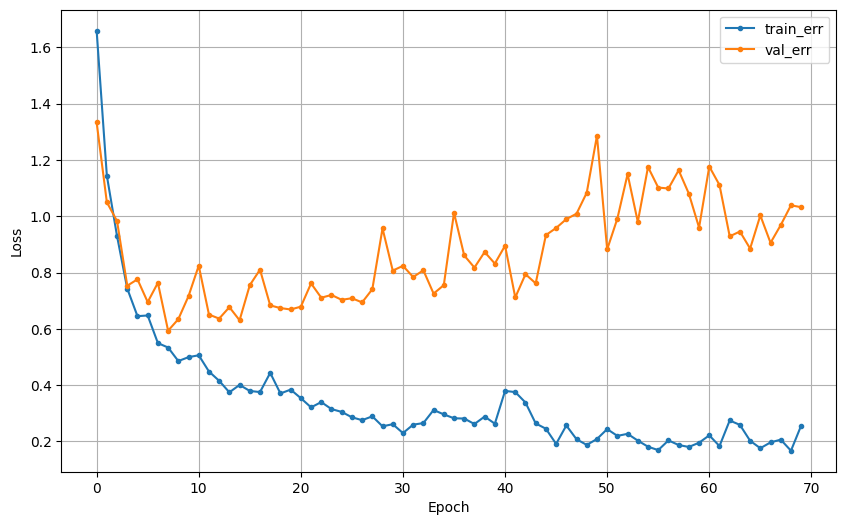

In [30]:
dl_history_plot(history)

#### ③ 예측 및 검증평가

In [33]:
pred = model.predict(x_val)
pred = np.argmax(pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step


In [34]:
print(accuracy_score(y_val,pred))
print('-'*60)
print(confusion_matrix(y_val, pred))
print('-'*60)
print(classification_report(y_val, pred))

0.805
------------------------------------------------------------
[[ 68   0   4   1   0   0  24   0   2   0]
 [  2 100   1   2   0   0   1   0   0   0]
 [  0   0  65   0  13   0   8   0   1   0]
 [  4   0   1  79  12   0   8   0   0   0]
 [  0   0  10   9  66   0  12   0   2   0]
 [  0   0   0   0   0  86   0   2   1   3]
 [ 12   0  11   0  11   1  58   0   0   0]
 [  0   0   0   0   0   6   0  81   0   6]
 [  0   0   4   1   0   2   1   0  90   0]
 [  0   0   0   0   0   7   0  10   0 112]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.69      0.74        99
           1       1.00      0.94      0.97       106
           2       0.68      0.75      0.71        87
           3       0.86      0.76      0.81       104
           4       0.65      0.67      0.66        99
           5       0.84      0.93      0.89        92
           6       0.52      0.62      0.57        93
        

### 2) early stopping
* 모델1에 대해서, early stopping으로 과적합을 예방해 봅시다.

#### ① 모델설계

In [48]:
nfeatures = x_train.shape[1]

model = Sequential([Input(shape=(nfeatures, )),
                    Dense(128, activation='relu'),
                    Dense(64, activation='relu'),
                    Dense(32, activation='relu'),
                    Dense(16, activation='relu'),
                    Dense(10, activation='softmax')
                    ])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_37 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

#### ② 학습

In [49]:
model.compile(optimizer=Adam(learning_rate=0.01), loss = 'sparse_categorical_crossentropy')

In [50]:
# EarlyStopping 설정 ------------------
es = EarlyStopping(monitor='val_loss', min_delta=0.001, patience=5)

history = model.fit(x_train, y_train, epochs=100, validation_split=0.2, callbacks= [es]).history

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 1.4480 - val_loss: 0.8884
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7528 - val_loss: 0.6715
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6525 - val_loss: 0.6610
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5866 - val_loss: 0.5957
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5466 - val_loss: 0.5456
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4843 - val_loss: 0.5708
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4641 - val_loss: 0.5619
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4845 - val_loss: 0.6138
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5022 - val_loss: 0.5705
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4153 - val_loss: 0.5534


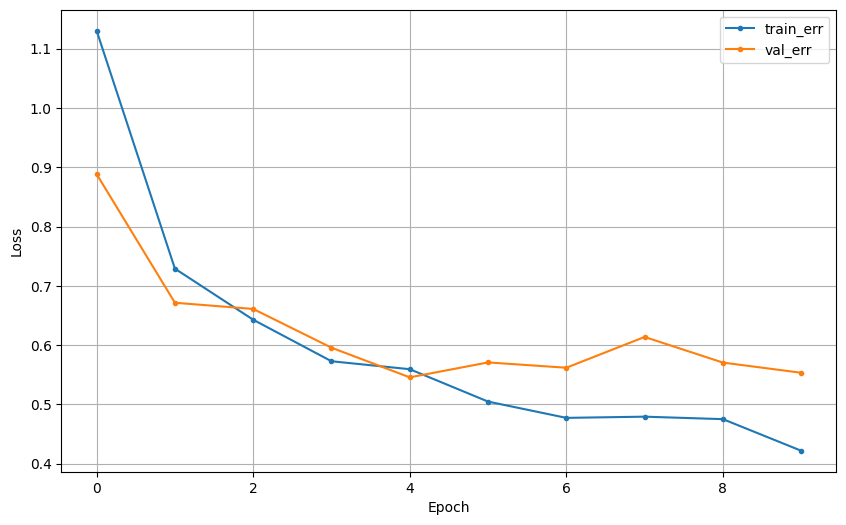

In [51]:
dl_history_plot(history)

# 과적합이 위의 그래프보다는 완화 되었다.

#### ③ 예측 및 검증평가

In [52]:
pred = model.predict(x_val)
pred = np.argmax(pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [53]:
print(accuracy_score(y_val,pred))
print('-'*60)
print(confusion_matrix(y_val, pred))
print('-'*60)
print(classification_report(y_val, pred))

0.823
------------------------------------------------------------
[[ 85   0   2   4   1   0   2   0   5   0]
 [  0 102   1   3   0   0   0   0   0   0]
 [  4   0  62   1  17   0   1   0   2   0]
 [  2   0   0  91   6   0   5   0   0   0]
 [  0   0  10   8  74   0   4   0   3   0]
 [  0   0   0   0   0  85   0   2   0   5]
 [ 22   0  10   7  23   0  29   0   2   0]
 [  0   0   0   0   0   2   0  80   0  11]
 [  1   0   0   1   0   0   2   0  93   1]
 [  0   0   0   0   0   0   0   7   0 122]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.75      0.86      0.80        99
           1       1.00      0.96      0.98       106
           2       0.73      0.71      0.72        87
           3       0.79      0.88      0.83       104
           4       0.61      0.75      0.67        99
           5       0.98      0.92      0.95        92
           6       0.67      0.31      0.43        93
        

### 3) Dropout
* 모델1에 대해서, Dropout으로 과적합을 방지해 봅시다.

#### ① 모델설계

In [72]:
nfeatures = x_train.shape[1]
drop_rate = 0.3

model = Sequential([Input(shape=(nfeatures, )),
                    Dense(128, activation='relu'),
                    Dropout(drop_rate),
                    Dense(64, activation='relu'),
                    Dropout(drop_rate),
                    Dense(32, activation='relu'),
                    Dropout(drop_rate),
                    Dense(16, activation='relu'),
                    Dropout(drop_rate),
                    Dense(10, activation='softmax')
                    ])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_55 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_56 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_57 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_58 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_59 (Dense)                     │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 111,514 (435.60 KB)

 Trainable params: 111,514 (435.60 KB)

 Non-trainable params: 0 (0.00 B)

#### ② 학습

In [73]:
model.compile(optimizer=Adam(learning_rate=0.01), loss = 'sparse_categorical_crossentropy')

In [74]:
history = model.fit(x_train, y_train, epochs=100, validation_split=0.2).history

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.2258 - val_loss: 1.2921
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5071 - val_loss: 1.1711
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3936 - val_loss: 0.9186
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2377 - val_loss: 0.8464
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1168 - val_loss: 0.7813
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1650 - val_loss: 0.8059
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1576 - val_loss: 0.7552
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1464 - val_loss: 0.8180
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0416 - val_loss: 0.7174
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1017 - val_loss: 0.8209
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0510 - val_loss: 0.7736
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━━

#### ③ 예측 및 검증평가

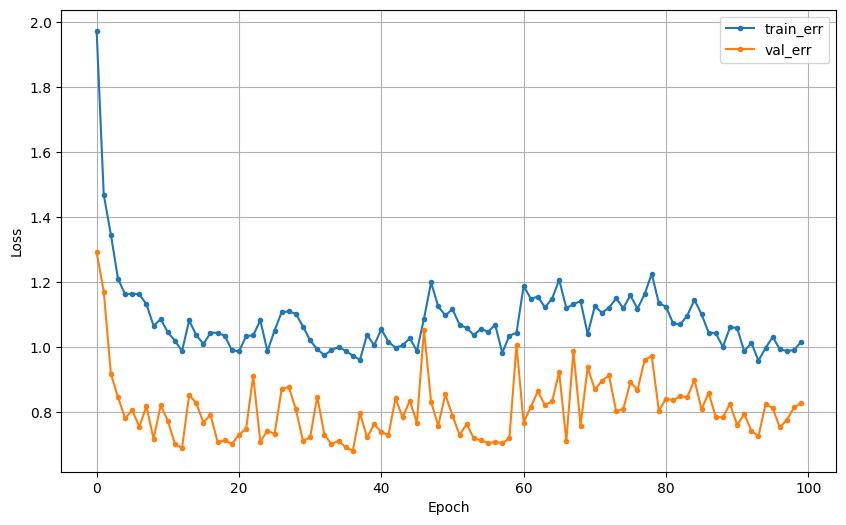

In [75]:
dl_history_plot(history)

## 과적합이 완화 되었음!!!!!

In [76]:
pred = model.predict(x_val)
pred = np.argmax(pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [77]:
print(accuracy_score(y_val,pred))
print('-'*60)
print(confusion_matrix(y_val, pred))
print('-'*60)
print(classification_report(y_val, pred))

0.705
------------------------------------------------------------
[[ 73   0  12   8   0   0   1   0   5   0]
 [  0  99   1   5   1   0   0   0   0   0]
 [  0   0  20   1  66   0   0   0   0   0]
 [  1   0  14  86   1   0   0   0   2   0]
 [  0   0  16   6  75   0   0   0   2   0]
 [  0   0   0   0   0  86   0   2   1   3]
 [ 12   0  22  11  43   1   2   0   2   0]
 [  0   0   0   0   0  21   0  66   0   6]
 [  0   0   6   2   0   0   0   1  89   0]
 [  0   0   0   0   0  17   0   3   0 109]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.74      0.79        99
           1       1.00      0.93      0.97       106
           2       0.22      0.23      0.22        87
           3       0.72      0.83      0.77       104
           4       0.40      0.76      0.53        99
           5       0.69      0.93      0.79        92
           6       0.67      0.02      0.04        93
        